# Financial Market Regime & Event Intelligence Engine
## Notebook 08: Market Regime Explainability via Supervised SHAP Surrogate

Welcome to Notebook 08! In this notebook, we introduce **Explainable AI (XAI)** to the Market Regime Engine by applying **SHAP (SHapley Additive exPlanations)** to interpret the quantitative boundaries defining HMM market regimes.

### Objectives:
1. **Recreate HMM Pipeline**: Download daily data (`^GSPC`, `TLT`, `GLD`), construct the 6-feature matrix, and decode 4 Gaussian HMM market regime states.
2. **Train Supervised Surrogate Model**: Train a `RandomForestClassifier` to map the 6 market features to decoded HMM state labels using a chronological 80/20 train/test split.
3. **Evaluate Surrogate Fidelity**: Measure how accurately the surrogate model reproduces HMM state assignments (Accuracy, Macro F1 for present classes, Macro F1 for all 4 states, Confusion Matrix).
4. **Global SHAP Analysis Across Historical Regimes**: Calculate global SHAP feature importances across representative historical observations so all four HMM states are represented.
5. **Local Observation SHAP Breakdown**: Explain individual test day regime predictions using local SHAP waterfall plots and feature contribution tables.
6. **Financial Interpretation & Limitations**: Interpret feature impacts in economic terms and document model disclaimers.

---
### Step 1: Conceptual Framework & Surrogate Approach

#### Why a Surrogate Model is Required:
- The **Gaussian Hidden Markov Model (HMM)** is an *unsupervised, sequential latent-variable model* governed by transition matrices and continuous multivariate emission distributions.
- **SHAP (SHapley Additive exPlanations)** is designed for *supervised feature-to-label models* to calculate game-theoretic marginal feature contributions.
- Direct application of SHAP to sequential unsupervised HMM transition mechanics is conceptually non-trivial and mathematically ill-defined.

#### The Supervised Surrogate Workflow:
1. We train a supervised decision tree ensemble (`RandomForestClassifier`) to predict the decoded HMM state ($s_t$) from the 6 quantitative market features ($X_t$).
2. We evaluate **Surrogate Fidelity** — how closely $f_{\text{surrogate}}(X_t)$ replicates the HMM state decodes $s_t$.
3. We apply SHAP `TreeExplainer` to the surrogate model to reveal the precise feature thresholds and non-linear interactions driving regime assignments.

#### Strict Conceptual Distinction:
- **HMM State Detection**: Unsupervised sequential state decoding from multivariate financial emissions.
- **Surrogate Model**: Supervised decision-tree classifier trained to mimic HMM state labels.
- **SHAP Explanation**: Game-theoretic feature attribution explaining the surrogate model's decision rules.

---
### Step 2: Import Required Libraries

**Why we do this:**
- `pandas` & `numpy`: Data handling and array manipulation.
- `matplotlib.pyplot`: Custom visualization rendering.
- `yfinance`: Downloading historical asset prices.
- `sklearn.preprocessing.StandardScaler`: Standardizing features for HMM fitting.
- `hmmlearn.hmm.GaussianHMM`: 4-state Gaussian HMM market regime model.
- `sklearn.ensemble.RandomForestClassifier`: Supervised tree surrogate model.
- `sklearn.metrics`: Evaluating surrogate fidelity (Accuracy, Macro F1, Confusion Matrix).
- `shap`: Game-theoretic model explainability framework.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import shap
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 90)
print("Libraries successfully imported!")

Libraries successfully imported!


---
### Step 3: Recreate Market Data & 4-State Gaussian HMM Pipeline

We download 5 years of daily market data (`^GSPC`, `TLT`, `GLD`), construct the exact 6 quantitative features, standardize inputs, and fit the 4-state Gaussian HMM.

In [2]:
# Download historical closing prices
sp500_close = yf.download("^GSPC", period="5y", interval="1d")["Close"]
tlt_close = yf.download("TLT", period="5y", interval="1d")["Close"]
gld_close = yf.download("GLD", period="5y", interval="1d")["Close"]

if isinstance(sp500_close, pd.DataFrame): sp500_close = sp500_close.squeeze()
if isinstance(tlt_close, pd.DataFrame): tlt_close = tlt_close.squeeze()
if isinstance(gld_close, pd.DataFrame): gld_close = gld_close.squeeze()

# Construct Quantitative Financial Features
daily_return = sp500_close.pct_change()
vol_20 = daily_return.rolling(window=20).std()
mom_20 = sp500_close.pct_change(periods=20)
peak = sp500_close.cummax()
drawdown = (sp500_close - peak) / peak

tlt_return = tlt_close.pct_change()
gld_return = gld_close.pct_change()

corr_sp_tlt = daily_return.rolling(window=20).corr(tlt_return)
corr_sp_gld = daily_return.rolling(window=20).corr(gld_return)

feature_names = [
    "Daily_Return", "Rolling_Volatility_20", "Momentum_20",
    "Drawdown", "SP500_TLT_Corr_20", "SP500_GLD_Corr_20"
]

market_raw_df = pd.DataFrame({
    "Close": sp500_close,
    "Daily_Return": daily_return,
    "Rolling_Volatility_20": vol_20,
    "Momentum_20": mom_20,
    "Drawdown": drawdown,
    "SP500_TLT_Corr_20": corr_sp_tlt,
    "SP500_GLD_Corr_20": corr_sp_gld
})

# Remove incomplete rolling rows
market_clean_df = market_raw_df.dropna(subset=feature_names).copy()

# Standardize features & fit 4-state Gaussian HMM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(market_clean_df[feature_names])

hmm_model = GaussianHMM(n_components=4, covariance_type="full", n_iter=200, random_state=42)
hmm_model.fit(X_scaled)
market_clean_df["HMM_State"] = hmm_model.predict(X_scaled)

print(f"Market & HMM Data ready. Total observations: {len(market_clean_df)}")
print("Decoded HMM State Frequencies:")
print(market_clean_df["HMM_State"].value_counts().sort_index())

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

Market & HMM Data ready. Total observations: 1235
Decoded HMM State Frequencies:
HMM_State
0    418
1    303
2    247
3    267
Name: count, dtype: int64


---
### Step 4: Chronological Train/Test Split & Surrogate Model Training

We split the dataset **chronologically** (80% training set, 20% test set) without shuffling to strictly respect time series sequence. We fit a `RandomForestClassifier` as our surrogate explainer.

In [3]:
X = market_clean_df[feature_names]
y = market_clean_df["HMM_State"]

# Chronological Train/Test Split (80% Train, 20% Test)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Chronological Split: Training samples = {len(X_train)} ({X_train.index.min().strftime('%Y-%m-%d')} to {X_train.index.max().strftime('%Y-%m-%d')})")
print(f"Chronological Split: Testing samples  = {len(X_test)} ({X_test.index.min().strftime('%Y-%m-%d')} to {X_test.index.max().strftime('%Y-%m-%d')})")

# Train Random Forest Surrogate Model
rf_surrogate = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_surrogate.fit(X_train, y_train)
print("Random Forest Surrogate Model trained successfully!")

Chronological Split: Training samples = 988 (2021-10-18 to 2025-09-24)
Chronological Split: Testing samples  = 247 (2025-09-25 to 2026-09-18)


Random Forest Surrogate Model trained successfully!


---
### Step 5: Evaluate Primary Out-of-Sample Surrogate Fidelity

#### What is Surrogate Fidelity?
- **Surrogate Fidelity** measures how accurately the Random Forest surrogate reproduces the unsupervised HMM's state assignments on out-of-sample test data.
- High surrogate fidelity validates that SHAP feature attributions on the Random Forest accurately reflect the quantitative decision boundaries of the HMM.
- *Note*: This evaluates model approximation quality, **NOT** predictive accuracy of future asset prices or returns.

> **Test Period State Distribution Disclaimer**:
> The chronological test period contains only HMM States 0 and 3. Therefore, out-of-sample surrogate fidelity can only be directly evaluated for those states. Metrics involving all four labels assign zero support to States 1 and 2 and should not be interpreted as evidence of poor classification of those states.

In [4]:
y_pred = rf_surrogate.predict(X_test)

surrogate_acc = accuracy_score(y_test, y_pred)
present_classes = np.unique(y_test)
macro_f1_present = f1_score(y_test, y_pred, labels=present_classes, average="macro")
macro_f1_all = f1_score(y_test, y_pred, labels=[0, 1, 2, 3], average="macro", zero_division=0)
all_states = [0, 1, 2, 3]
surrogate_cm = confusion_matrix(y_test, y_pred, labels=all_states)

print("=== SURROGATE MODEL FIDELITY EVALUATION ===")
print(f"Primary Test Accuracy                   : {surrogate_acc:.4f}")
print(f"Macro F1 (Classes Present in Test {present_classes.tolist()}): {macro_f1_present:.4f}")
print(f"Macro F1 (All 4 HMM States [0, 1, 2, 3])   : {macro_f1_all:.4f}  (Note: States 1 & 2 have 0 support in test period)\n")

print("--- Test Set State Counts ---")
test_state_counts = pd.Series(y_test).value_counts().reindex(all_states, fill_value=0)
for s, cnt in test_state_counts.items():
    print(f"  HMM State {s}: {cnt:>3} samples")

print("\n--- Full Classification Report (All 4 States) ---")
print(classification_report(y_test, y_pred, labels=all_states, zero_division=0))

print("--- Confusion Matrix (All 4 HMM States) ---")
cm_df = pd.DataFrame(
    surrogate_cm,
    index=[f"Actual HMM State {i}" for i in all_states],
    columns=[f"Pred Surrogate State {i}" for i in all_states]
)
display(cm_df)

=== SURROGATE MODEL FIDELITY EVALUATION ===
Primary Test Accuracy                   : 0.8543
Macro F1 (Classes Present in Test [0, 3]): 0.8741
Macro F1 (All 4 HMM States [0, 1, 2, 3])   : 0.4370  (Note: States 1 & 2 have 0 support in test period)

--- Test Set State Counts ---
  HMM State 0: 118 samples
  HMM State 1:   0 samples
  HMM State 2:   0 samples
  HMM State 3: 129 samples

--- Full Classification Report (All 4 States) ---
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       118
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.90      0.81      0.85       129

    accuracy                           0.85       247
   macro avg       0.45      0.43      0.44       247
weighted avg       0.89      0.85      0.87       247

--- Confusion Matrix (All 4 HMM States) ---


,Pred Surrogate State 0,Pred Surrogate State 1,Pred Surrogate State 2,Pred Surrogate State 3
Actual HMM State 0,106,0,0,12
Actual HMM State 1,0,0,0,0
Actual HMM State 2,0,0,0,0
Actual HMM State 3,13,11,0,105


---
### Step 6: Global SHAP Analysis Across Historical Regimes

To ensure global feature importance is not restricted to the 2025–2026 low-volatility test window, we use the trained Random Forest surrogate model to compute SHAP values across representative historical observations covering the full 5-year dataset ($N=1,235$), ensuring all four HMM states are represented.

*Note: The surrogate model remains trained strictly on the training split $X_{\text{train}}$ and is NOT retrained on future data.*

--- Global SHAP Feature Importance Table (Full Historical Regimes) ---


,Feature,Mean_Absolute_SHAP
0,Drawdown,0.1929
1,Momentum_20,0.1125
2,Rolling_Volatility_20,0.0692
3,SP500_TLT_Corr_20,0.0466
4,SP500_GLD_Corr_20,0.0413
5,Daily_Return,0.0059


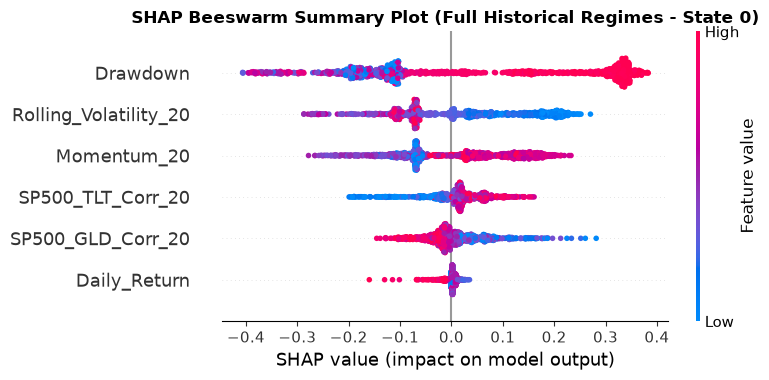

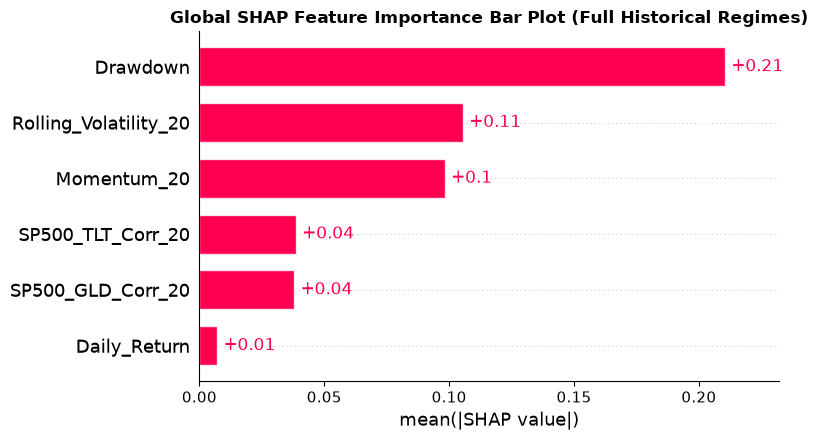

In [5]:
# Initialize SHAP TreeExplainer on trained surrogate model
explainer = shap.TreeExplainer(rf_surrogate)

# Compute SHAP values across full historical dataset X so all 4 states are represented
shap_full = explainer(X)

# 1. Global Mean Absolute SHAP Feature Importance Table across full historical regimes
mean_abs_shap_full = np.abs(shap_full.values).mean(axis=(0, 2))
global_shap_full_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap_full
}).sort_values(by="Mean_Absolute_SHAP", ascending=False).reset_index(drop=True)

print("--- Global SHAP Feature Importance Table (Full Historical Regimes) ---")
display(global_shap_full_df.round(4))

# 2. SHAP Summary Beeswarm Plot across full historical period (State 0 representative)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_full[:, :, 0], show=False)
plt.title("SHAP Beeswarm Summary Plot (Full Historical Regimes - State 0)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. SHAP Feature Importance Bar Plot
plt.figure(figsize=(9, 5))
shap.plots.bar(shap_full[:, :, 0], show=False)
plt.title("Global SHAP Feature Importance Bar Plot (Full Historical Regimes)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
### Step 7: Local Observation SHAP Explanation

We select an individual observation from the out-of-sample test set (`2025-09-25`) to inspect local SHAP feature attributions using a Waterfall Plot.

=== Local Observation Inspection (2025-09-25) ===
Observation Date           : 2025-09-25
Actual HMM Decoded State   : State 0
Surrogate Predicted State : State 0
Correct Prediction        : True

--- Feature Values for Observation ---
  Daily_Return          : -0.005009
  Rolling_Volatility_20 : +0.004777
  Momentum_20           : +0.019027
  Drawdown              : -0.013300
  SP500_TLT_Corr_20     : +0.235743
  SP500_GLD_Corr_20     : -0.228333


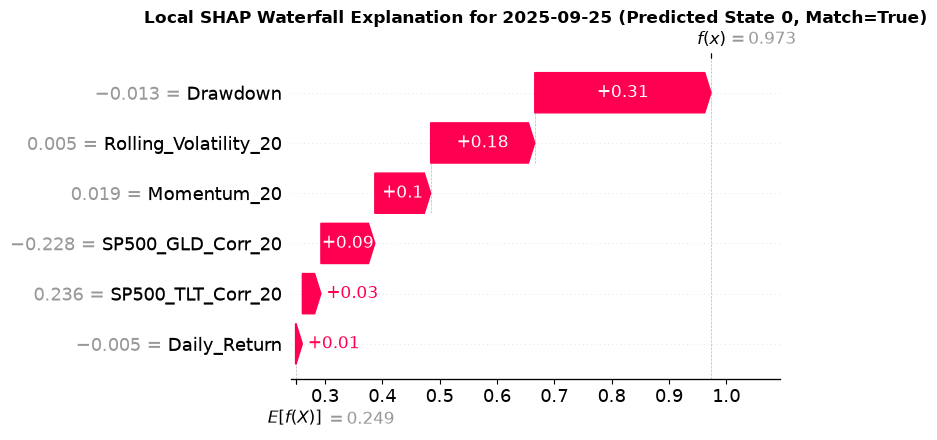

In [6]:
sample_idx = 0
sample_date = X_test.index[sample_idx].strftime("%Y-%m-%d")
actual_hmm_state = int(y_test.iloc[sample_idx])
pred_surrogate_state = int(y_pred[sample_idx])
is_correct = (actual_hmm_state == pred_surrogate_state)
sample_features = X_test.iloc[sample_idx]

print(f"=== Local Observation Inspection ({sample_date}) ===")
print(f"Observation Date           : {sample_date}")
print(f"Actual HMM Decoded State   : State {actual_hmm_state}")
print(f"Surrogate Predicted State : State {pred_surrogate_state}")
print(f"Correct Prediction        : {is_correct}")
print("\n--- Feature Values for Observation ---")
for feat, val in sample_features.items():
    print(f"  {feat:<22}: {val:+.6f}")

# Compute test set SHAP for waterfall plot
shap_test = explainer(X_test)

# Plot Waterfall for this observation for the predicted state
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_test[sample_idx, :, pred_surrogate_state], show=False)
plt.title(f"Local SHAP Waterfall Explanation for {sample_date} (Predicted State {pred_surrogate_state}, Match={is_correct})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
### Step 8: Financial Interpretation of SHAP Explainability

1. **`Drawdown` Has the Highest Global Contribution**:
   - `Drawdown` is the single most decisive feature defining market regimes. Severe cumulative drawdowns distinctly demarcate High-Volatility Bear (State 1) and Volatile Recovery (State 2) regimes from Low-Volatility Bull (State 0) regimes.

2. **`Momentum_20` is the Second-Highest Driver**:
   - 20-day price momentum provides crucial directional context, separating trending recovery regimes from persistent downward sell-offs.

3. **Volatility & Cross-Asset Correlations Provide Additional Regime Separation**:
   - `Rolling_Volatility_20` acts as a sharp threshold for turbulent vs. calm regimes.
   - Cross-asset correlations (`SP500_TLT_Corr_20` & `SP500_GLD_Corr_20`) provide macroeconomic context regarding Treasury flight-to-safety and commodity hedging behaviors.

4. **`Daily_Return` Has Relatively Low Global Contribution**:
   - Daily single-session return has low global SHAP contribution because individual daily price noise lacks the cumulative multi-week signal required to define persistent market regimes.

---
### Step 9: Limitations of Surrogate SHAP Explainability

1. **Surrogate Approximation Limit**: SHAP explains the Random Forest surrogate's approximation of HMM state assignments, not the internal HMM transition/emission mechanism.
2. **Latent Model-Derived Labels**: HMM states are statistical latent clusters derived from quantitative market data rather than directly observable physical states.
3. **Multicollinearity Impact**: Financial features (e.g., Drawdown, Volatility, Momentum) exhibit correlation, which can distribute SHAP values across co-linear variables.
4. **Fidelity Dependency**: The validity of the SHAP explanation relies on maintaining high surrogate fidelity.
5. **No Trading Advice**: This analysis is strictly historical and observational. It does not constitute trading signals or financial advice.

In [7]:
# Final Summary Output Print/Display Report
print("=========================================================")
print("   EXPLAINABLE HMM REGIME SURROGATE SUMMARY REPORT")
print("=========================================================")
print(f"1. Primary Test Accuracy                : {surrogate_acc:.4f}")
print(f"2. Macro F1 (Classes Present in Test [0, 3]): {macro_f1_present:.4f}")
print(f"3. Macro F1 (Across All 4 States [0, 1, 2, 3]): {macro_f1_all:.4f}  (Note: States 1 & 2 have 0 support in test period)")
print("\n4. Test Set State Counts:")
for s, cnt in test_state_counts.items():
    print(f"   State {s}: {cnt:>3} samples")
print("\n5. Global SHAP Feature Importance Ranking (Full Historical Regimes):")
for rank, row in global_shap_full_df.iterrows():
    print(f"   Rank {rank+1}: {row['Feature']:<22} (Mean |SHAP| = {row['Mean_Absolute_SHAP']:.6f})")
print(f"\n6. Local SHAP Explanation Sample ({sample_date}):")
print(f"   Actual HMM State    : State {actual_hmm_state}")
print(f"   Predicted Surrogate : State {pred_surrogate_state}")
print(f"   Prediction Match    : {is_correct}")
print("=========================================================")

   EXPLAINABLE HMM REGIME SURROGATE SUMMARY REPORT
1. Primary Test Accuracy                : 0.8543
2. Macro F1 (Classes Present in Test [0, 3]): 0.8741
3. Macro F1 (Across All 4 States [0, 1, 2, 3]): 0.4370  (Note: States 1 & 2 have 0 support in test period)

4. Test Set State Counts:
   State 0: 118 samples
   State 1:   0 samples
   State 2:   0 samples
   State 3: 129 samples

5. Global SHAP Feature Importance Ranking (Full Historical Regimes):
   Rank 1: Drawdown               (Mean |SHAP| = 0.192868)
   Rank 2: Momentum_20            (Mean |SHAP| = 0.112512)
   Rank 3: Rolling_Volatility_20  (Mean |SHAP| = 0.069222)
   Rank 4: SP500_TLT_Corr_20      (Mean |SHAP| = 0.046619)
   Rank 5: SP500_GLD_Corr_20      (Mean |SHAP| = 0.041344)
   Rank 6: Daily_Return           (Mean |SHAP| = 0.005900)

6. Local SHAP Explanation Sample (2025-09-25):
   Actual HMM State    : State 0
   Predicted Surrogate : State 0
   Prediction Match    : True
